In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split,KFold,StratifiedKFold,StratifiedShuffleSplit,cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score,f1_score,recall_score,confusion_matrix,classification_report,precision_score

In [2]:
df = pd.read_csv("email_dataset.csv")
df.head()

,from,to,subject,date,body,label
0,Robert Elz <kre@munnari.OZ.AU>,Chris Garrigues <cwg-dated-1030377287.06fa6d@D...,Re: New Sequences Window,"Thu, 22 Aug 2002 18:26:25 +0700","Date: Wed, 21 Aug 2002 10:54:46 -05...",0
1,Steve Burt <Steve_Burt@cursor-system.com>,"""'zzzzteana@yahoogroups.com'"" <zzzzteana@yahoo...",[zzzzteana] RE: Alexander,"Thu, 22 Aug 2002 12:46:18 +0100","Martin A posted:\nTassos Papadopoulos, the Gre...",0
2,Tim Chapman <timc@2ubh.com>,zzzzteana <zzzzteana@yahoogroups.com>,[zzzzteana] Moscow bomber,"Thu, 22 Aug 2002 13:52:38 +0100",Man Threatens Explosion In Moscow \n\nThursday...,0
3,Monty Solomon <monty@roscom.com>,undisclosed-recipient:;,[IRR] Klez: The Virus That Won't Die,"Thu, 22 Aug 2002 09:15:25 -0400",Klez: The Virus That Won't Die\n \nAlready the...,0
4,Stewart Smith <Stewart.Smith@ee.ed.ac.uk>,zzzzteana@yahoogroups.com,Re: [zzzzteana] Nothing like mama used to make,"Thu, 22 Aug 2002 14:38:22 +0100","> in adding cream to spaghetti carbonara, whi...",0


In [3]:
df.shape

(3000, 6)

In [4]:
df.columns

Index(['from', 'to', 'subject', 'date', 'body', 'label'], dtype='str')

In [5]:
df.dtypes

from         str
to           str
subject      str
date         str
body         str
label      int64
dtype: object

In [6]:
df.isnull().sum()

from         0
to         156
subject      2
date         0
body        28
label        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(6)

In [8]:
df = df.drop_duplicates()
df.shape
df.duplicated().sum()

np.int64(0)

In [9]:
df['label'].value_counts()

label
0    2498
1     496
Name: count, dtype: int64

In [10]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df['to'] = df['to'].fillna("")

In [11]:
print("\nMissing values after cleaning:")
print(df[["to","subject", "body"]].isnull().sum())
print("\n\n\n")
print(df.isnull().sum())


Missing values after cleaning:
to         0
subject    0
body       0
dtype: int64




from       0
to         0
subject    0
date       0
body       0
label      0
dtype: int64


In [12]:
df['email_text']=df['subject']+ "  " +df['body']

In [13]:
display(df[["subject", "body", "email_text", "label"]].head())

,subject,body,email_text,label
0,Re: New Sequences Window,"Date: Wed, 21 Aug 2002 10:54:46 -05...",Re: New Sequences Window Date: Wed...,0
1,[zzzzteana] RE: Alexander,"Martin A posted:\nTassos Papadopoulos, the Gre...",[zzzzteana] RE: Alexander Martin A posted:\nT...,0
2,[zzzzteana] Moscow bomber,Man Threatens Explosion In Moscow \n\nThursday...,[zzzzteana] Moscow bomber Man Threatens Explo...,0
3,[IRR] Klez: The Virus That Won't Die,Klez: The Virus That Won't Die\n \nAlready the...,[IRR] Klez: The Virus That Won't Die Klez: T...,0
4,Re: [zzzzteana] Nothing like mama used to make,"> in adding cream to spaghetti carbonara, whi...",Re: [zzzzteana] Nothing like mama used to make...,0


In [14]:
print("Unique labels:")
print(df["label"].unique())

print("\nLabel counts:")
print(df["label"].value_counts())

Unique labels:
[0 1]

Label counts:
label
0    2498
1     496
Name: count, dtype: int64


In [15]:
print("\nLabel percentage:")
print(df["label"].value_counts(normalize=True) * 100)


Label percentage:
label
0    83.433534
1    16.566466
Name: proportion, dtype: float64


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

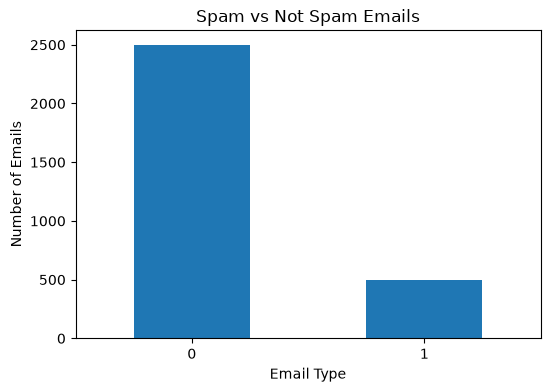

In [16]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()
plt.figure(figsize=(6,4))
label_counts.plot(kind="bar")

plt.title("Spam vs Not Spam Emails")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")

plt.xticks(rotation=1)

In [17]:
X = df["email_text"]
y= df["label"]

In [18]:

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 X values:")
print(X.head())


print("\nFirst 5 y values:")
print(y.head())

X shape: (2994,)
y shape: (2994,)

First 5 X values:
0    Re: New Sequences Window      Date:        Wed...
1    [zzzzteana] RE: Alexander  Martin A posted:\nT...
2    [zzzzteana] Moscow bomber  Man Threatens Explo...
3    [IRR] Klez: The Virus That  Won't Die  Klez: T...
4    Re: [zzzzteana] Nothing like mama used to make...
Name: email_text, dtype: str

First 5 y values:
0    0
1    0
2    0
3    0
4    0
Name: label, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 2395
Testing samples : 599


In [20]:
# train_test_split(X, y, test_size=0.20)

In [21]:

print("Original dataset:")
print(y.value_counts(normalize=True))

print("\nTraining dataset:")
print(y_train.value_counts(normalize=True))

print("\nTesting dataset:")
print(y_test.value_counts(normalize=True))

Original dataset:
label
0    0.834335
1    0.165665
Name: proportion, dtype: float64

Training dataset:
label
0    0.834238
1    0.165762
Name: proportion, dtype: float64

Testing dataset:
label
0    0.834725
1    0.165275
Name: proportion, dtype: float64


In [22]:
tfidf  =TfidfVectorizer(lowercase=True,stop_words="english",max_features=5000)


In [23]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [24]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (2395, 5000)
Testing TF-IDF shape : (599, 5000)


In [25]:
model = MultinomialNB()

model.fit(X_train_tfidf,y_train)
y_pred = model.predict(X_test_tfidf)

In [26]:
print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])


First 10 actual values:
[0 0 0 0 0 0 0 0 0 0]

First 10 predicted values:
[0 0 0 0 0 0 0 0 0 0]


In [27]:
accuracy_score = accuracy_score(y_test,y_pred)
confusion_matrix = confusion_matrix(y_test,y_pred)
precision_score=precision_score(y_test,y_pred)
recall_score = recall_score(y_test,y_pred)


In [28]:
print("accuracy_score" , accuracy_score)
print("precision_score",precision_score)
print("recall_score",recall_score)

accuracy_score 0.9699499165275459
precision_score 1.0
recall_score 0.8181818181818182


<Axes: >

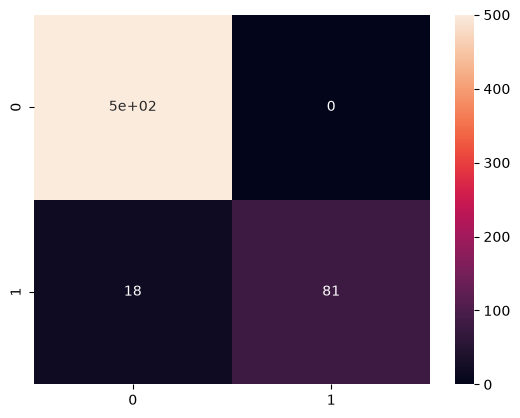

In [29]:
import seaborn as sns
sns.heatmap(confusion_matrix,annot=True)

In [30]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       500
           1       1.00      0.82      0.90        99

    accuracy                           0.97       599
   macro avg       0.98      0.91      0.94       599
weighted avg       0.97      0.97      0.97       599



In [41]:
new_email = [
 """
    Congratulations! You have been selected to receive a $10,000 cash prize.
    You are the lucky winner of our special promotion.
    Click the link below immediately to claim your prize.
    This offer is valid for a limited time only.
    """
]

In [42]:
new_email_tfidf = tfidf.transform(new_email)

In [43]:
new_prediction = model.predict(new_email_tfidf)

In [44]:
print("\nNew Email Prediction:",new_prediction)


New Email Prediction: [1]


In [45]:
if new_prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam Email")

Spam Email


In [47]:
with open("email_spam_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Naive Bayes model saved successfully!")
print("File: email_spam_model.pkl")

Naive Bayes model saved successfully!
File: email_spam_model.pkl


In [48]:
with open("tfidf.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("\nTF-IDF vectorizer saved successfully!")
print("File: tfidf_vectorizer.pkl")


TF-IDF vectorizer saved successfully!
File: tfidf_vectorizer.pkl


In [49]:
df.describe()

,label
count,2994.000000
mean,0.165665
std,0.371841
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000
